# 🧠 SENSE — Sentiment Extraction Natural Language Scoring Engine

> A dual-model NLP pipeline that extracts, scores, and compares sentiment from Amazon product reviews — using both rule-based **VADER** and transformer-based **RoBERTa** under one unified engine.
> SENSE's NLP engine was developed and benchmarked on a 5,000-review sample drawn from the Amazon Fine Food Reviews dataset (568K reviews total) as a real-world testbed — but the underlying model generalizes to any text: product reviews, app feedback, social media, support tickets, and more.

# 📋 Problem Statement

Customer reviews hold a wealth of opinion, emotion, and feedback — but making sense of them at scale requires more than just reading. SENSE tackles this challenge by building an end-to-end sentiment scoring pipeline.

**The four goals of SENSE:**

| Goal | Description |
|------|-------------|
| 🔍 Extract | Pull raw sentiment signals from unstructured review text |
| 📊 Score | Assign confidence-weighted sentiment scores to each review |
| ⚖️ Compare | Benchmark a fast rule-based model (VADER) against a deep transformer (RoBERTa) |
| 🔁 Package | Deliver a reusable `SENSE()` function that scores any text on demand |

The dataset of choice is the **Amazon Fine Food Reviews** — 568K real-world reviews covering a wide spectrum of products, writing styles, and sentiments.

# 📦 Dependencies

Loading the full toolkit that powers the SENSE pipeline — from data wrangling to deep learning inference.

| Library | Role in SENSE |
|---------|--------------|
| `pandas` / `numpy` | Tabular data loading, manipulation, and array operations |
| `matplotlib` / `seaborn` | All EDA and results visualizations |
| `nltk` | Tokenization, POS tagging, and VADER sentiment scoring |
| `transformers` | Loading and running the RoBERTa model from Hugging Face |
| `scipy` | Softmax normalization of RoBERTa raw logits |
| `sklearn` | Classification reports and confusion matrices for evaluation |
| `tqdm` | Progress tracking during large dataset inference loops |
| `wordcloud` | Generating visual word frequency clouds from review text |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
import nltk 

# 📂 Loading the Dataset — Amazon Fine Food Reviews

**Source:** [Kaggle — Amazon Fine Food Reviews](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews)

The full dataset contains **~568,000 reviews** spanning over a decade of Amazon food product feedback. Each row includes the review text, a star rating (1–5), product metadata, and user information.

For rapid prototyping, SENSE works with a **capped subset of 5000 reviews** — large enough to observe meaningful patterns, small enough to iterate fast.

**Key columns used in SENSE:**

| Column | Description |
|--------|-------------|
| `Id` | Unique review identifier — used as the key throughout the pipeline |
| `Score` | Star rating from 1 to 5 — the ground truth for sentiment |
| `Text` | Raw review text — the primary input to all models |
| `Summary` | Short review title |

> ⚠️ **Note:** `df.isnull().sum()` is run to check for missing values before any processing begins — a critical hygiene step before feeding text into NLP models.

In [2]:
#Read in data
df=pd.read_csv('/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv')
print(df.shape)
df=df.head(5000)
print(df.shape)

(568454, 10)
(5000, 10)


In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
#dataset overview 
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 5000
Columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 5000 non-null   object
 9   Text                    5000 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


In [5]:
#missing values 
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

# 📊 Exploratory Data Analysis

Before any modeling, SENSE takes a thorough look at the dataset's structure, distributions, and text characteristics. This section answers three key questions:

1. 🌟 **How are star ratings distributed?** — Are reviews balanced across 1–5 stars, or skewed?
2. 📏 **How long are reviews?** — Does review length vary by star rating?
3. ☁️ **What words dominate positive and negative reviews?** — What language signals sentiment?

### 📊 Bar Chart: Count of Reviews by Star Rating

**Result:** The dataset is dominated by 5-star reviews, with 1-star a distant second and 2/3/4-star ratings significantly underrepresented. This is confirmed numerically later — of the final labeled set, **3,846 reviews (78%) are Positive, 759 (15%) are Negative, and only 395 (8%) are Neutral**. This 78/15/8 split is the class imbalance that shapes every evaluation metric in this notebook.

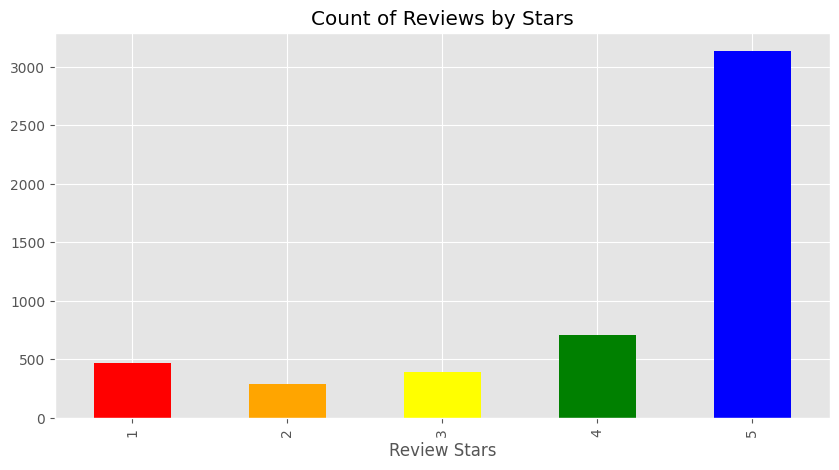

In [6]:
ax = df['Score'].value_counts().sort_index().plot(
    kind='bar',
    title='Count of Reviews by Stars',
    figsize=(10,5),
    color=['red', 'orange', 'yellow', 'green', 'blue']
)

ax.set_xlabel('Review Stars')
plt.show()

In [7]:
#review length
df['review_length'] = (
    df['Text']
    .astype(str)
    .apply(len)
)

### 📦 Boxplot: Review Length by Star Rating

**Result:** 1-star and 2-star reviews show wider length distributions — frustrated customers write longer explanations. 5-star reviews are shorter and more tightly clustered, consistent with quick, concise praise. This hints that longer (often negative) reviews carry more nuanced sentiment that a rule-based model like VADER may struggle with.

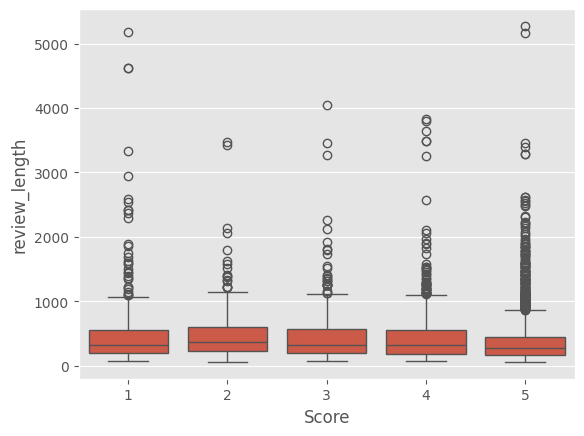

In [8]:
#boxplot
sns.boxplot(
    x='Score',
    y='review_length',
    data=df
)
plt.show()

### 📈 Histogram: Overall Review Length Distribution

**Result:** The distribution is right-skewed — most reviews are short to medium length, with a long tail of lengthy outliers. This long tail is exactly what produced the **44 reviews (0.88% of the dataset) that exceeded RoBERTa's 512-token limit** and were caught by the `try/except RuntimeError` guard (ids 83, 187, 529, 540, 746, 863, 1053, 1070, 1156, 1321, 1375, 1498, 1575, 1796, 1826, 2169, 2248, 2476, 2492, 2584, 2610, 2897, 2898, 2902, 2928, 2942, 2944, 2947, 2948, 3022, 3023, 3025, 3306, 3788, 3969, 4107, 4110, 4307, 4316, 4408, 4483, 4512, 4553, 4583).

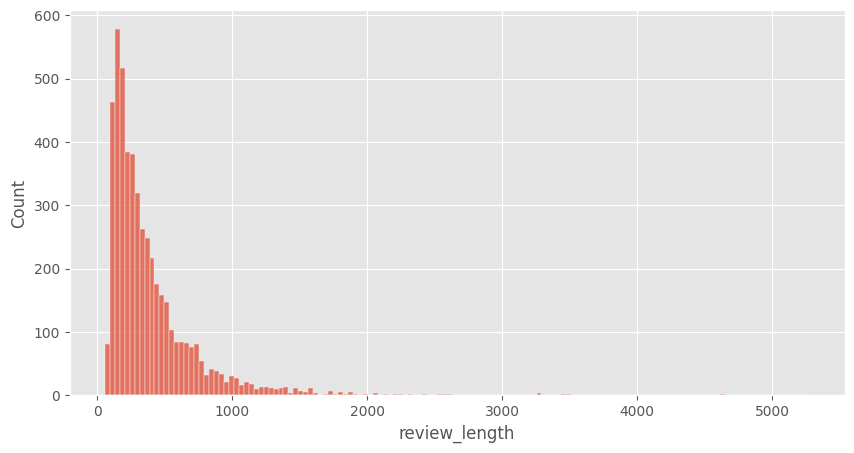

In [9]:
#histogram
plt.figure(figsize=(10,5))
sns.histplot(df['review_length'])
plt.show()

### ☁️ Word Cloud: Positive Reviews (Score ≥ 4)

**Result:** Words like **"great," "love," "good," "delicious," "best," "taste,"** and **"perfect"** dominate. The vocabulary is affirmative and flavor-focused — exactly the strong-polarity language VADER's lexicon is built to score highly, validating `Score ≥ 4` as a reliable proxy for positive text.

In [10]:
from wordcloud import WordCloud

In [11]:
positive_text = " ".join(
    df[df.Score >= 4]['Text'].astype(str)
)

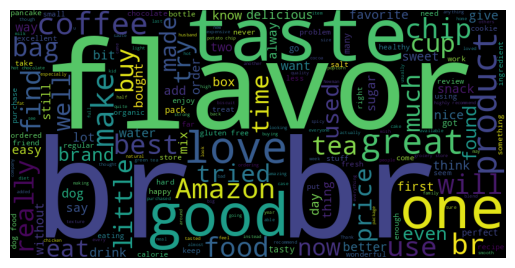

In [12]:
wordcloud = WordCloud(
    width=800,
    height=400
).generate(positive_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

### 🌧️ Word Cloud: Negative Reviews (Score ≤ 2)

**Result:** Negative reviews surface **"taste," "bad," "product," "not," "return," "terrible,"** and **"waste."** Notably, **"taste"** appears in both clouds — positive reviews praise it, negative reviews criticize it — showing why context (not just keywords) matters. The prominence of **"not"** is a key negation signal that helps explain VADER's reasonable performance and RoBERTa's stronger edge.

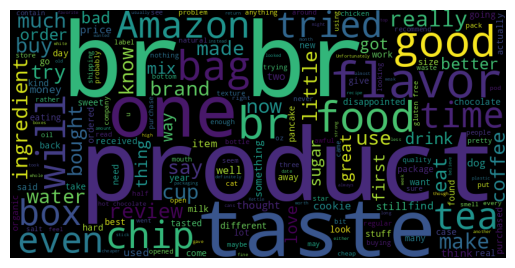

In [13]:
negative_text = " ".join(
    df[df.Score <= 2]['Text'].astype(str)
)

wordcloud = WordCloud(
    width=800,
    height=400
).generate(negative_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

# 🧹 Data Cleaning

Raw review text is noisy — full of URLs, punctuation, numbers, and inconsistent casing. SENSE applies a lightweight but effective cleaning pipeline before passing text to any model.

**Cleaning steps applied via `clean_text()`:**

| Step | What it does | Why it matters |
|------|-------------|----------------|
| `.lower()` | Converts all text to lowercase | Ensures "Great" and "great" are treated identically |
| `re.sub(r'http\S+', '', text)` | Strips all URLs | URLs carry no sentiment signal and add noise |
| `re.sub(r'[^a-zA-Z\s]', '', text)` | Removes numbers and punctuation | Reduces vocabulary noise for cleaner tokenization |

> 💡 The cleaned text is stored in a new column `clean_text`, preserving the original `Text` column for model inference — since VADER and RoBERTa are applied to the raw text, not the cleaned version.

In [14]:
import re

In [15]:
def clean_text(text):

    text = text.lower()

    text = re.sub(
        r'http\S+',
        '',
        text
    )

    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )

    return text

In [16]:
df['clean_text'] = (
    df['Text']
    .astype(str)
    .apply(clean_text)
)

### 🏷️ Sentiment Label Mapping

**Result:** Mapping star ratings (1-2 → Negative, 3 → Neutral, 4-5 → Positive) produced the ground-truth distribution:

| Sentiment | Count | % |
|-----------|-------|---|
| 😊 Positive | 3,846 | 77.6% |
| 😠 Negative | 759 | 15.3% |
| 😐 Neutral | 395 | 8.0% |

This confirms the skew seen in the star-rating bar chart and sets the bar for what "good" recall on the Neutral class will look like — it's a small class to begin with.

In [17]:

def create_label(score):

    if score <= 2:
        return 'Negative'

    elif score == 3:
        return 'Neutral'

    return 'Positive'

In [18]:
df['sentiment'] = (
    df['Score']
    .apply(create_label)
)

In [19]:
df['sentiment'].value_counts()

sentiment
Positive    3846
Negative     759
Neutral      395
Name: count, dtype: int64

# 🎯 Model Training — VADER (Rule-Based Baseline)

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is SENSE's first model — a fast, interpretable, lexicon-driven sentiment scorer built into NLTK. It requires no training data and runs in milliseconds per review, making it an ideal baseline.

VADER scores every review across four dimensions:

| Score | Range | What it captures |
|-------|-------|-----------------|
| `neg` | 0 to 1 | Proportion of text with negative sentiment |
| `neu` | 0 to 1 | Proportion of text that is neutral |
| `pos` | 0 to 1 | Proportion of text with positive sentiment |
| `compound` | –1 to +1 | Normalized aggregate — the primary signal for classification |

> 💡 `neg + neu + pos = 1.0` for every review. The `compound` score is the most important — values ≥ 0.05 are classified as Positive, ≤ –0.05 as Negative, and everything in between as Neutral.

In [20]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

### Running VADER on the Full Dataset

**Result:** All 5,000 reviews were scored successfully — VADER requires no model download and runs near-instantly, producing a `res` dictionary of `{Id: {neg, neu, pos, compound}}` for every row.

In [21]:
#Run the polarity score on the entire dataset
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    myid = row['Id']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/5000 [00:00<?, ?it/s]

### 🔗 Merging VADER Scores with Review Metadata

**Result:** The `vaders` DataFrame now contains each review's `Id`, its four VADER scores, and all original metadata (Score, Text, ProductId, etc.) — the foundation for every VADER chart and metric that follows.

In [22]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})

In [23]:
vaders = vaders.merge(df, on='Id', how='left')

In [24]:
#Now we have sentiment score and metadata
vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,review_length,clean_text,sentiment
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,263,i have bought several of the vitality canned d...,Positive
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,190,product arrived labeled as jumbo salted peanut...,Negative
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,509,this is a confection that has been around a fe...,Positive
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,219,if you are looking for the secret ingredient i...,Negative
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,140,great taffy at a great price there was a wide...,Positive


### 📊 Bar Chart: VADER Compound Score by Star Rating

**Result:** Compound scores rise monotonically from 1-star to 5-star — 5-star reviews average roughly **+0.8**, while 1-star reviews sit around **-0.3 to -0.5**. This confirms VADER's lexicon tracks star ratings as a reasonable first-pass signal. However, the gap between 3-star and 4-star bars is smaller than between other adjacent pairs, meaning VADER struggles most to separate moderate from strong satisfaction.

/tmp/ipykernel_23/2628530089.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


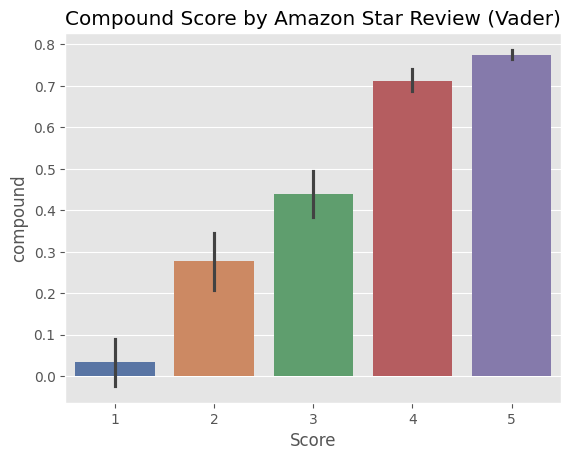

In [25]:
ax = sns.barplot(
    data=vaders,
    x='Score',
    y='compound',
    palette='deep'
)

ax.set_title('Compound Score by Amazon Star Review (Vader)')
plt.show()

### 📊 Triple Bar Chart: VADER Positive / Neutral / Negative by Star Rating

**Result:**
- **pos** rises steadily from 1-star to 5-star — high-polarity positive words concentrate in top-rated reviews.
- **neu** trends slightly downward as star rating increases — higher ratings replace neutral language with expressive positive terms.
- **neg** peaks sharply at 1-star and drops off quickly — negative vocabulary is concentrated almost entirely in the lowest ratings.

2-star and 3-star reviews show the most overlap across all three components — this is exactly where VADER's classification errors cluster (confirmed later in the confusion matrix, where Neutral to Positive is VADER's dominant error).

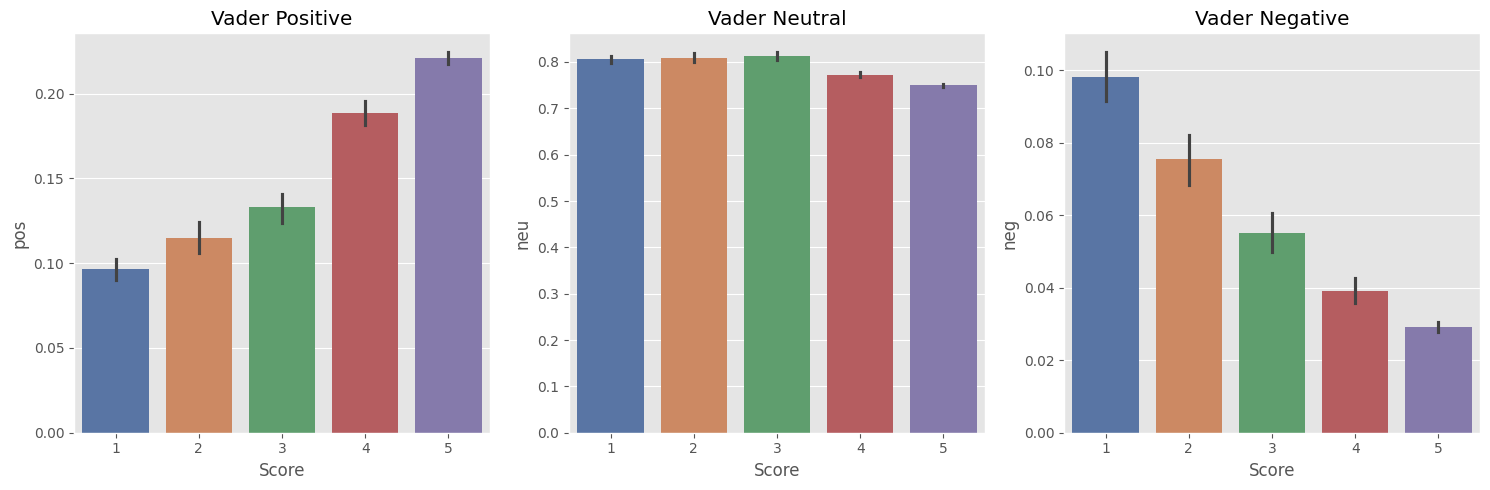

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(data=vaders, x='Score', y='pos', hue='Score', palette='deep', legend=False, ax=axs[0])
sns.barplot(data=vaders, x='Score', y='neu', hue='Score', palette='deep', legend=False, ax=axs[1])
sns.barplot(data=vaders, x='Score', y='neg', hue='Score', palette='deep', legend=False, ax=axs[2])

axs[0].set_title('Vader Positive')
axs[1].set_title('Vader Neutral')
axs[2].set_title('Vader Negative')

plt.tight_layout()
plt.show()

# 🤖 Model Training — RoBERTa (Transformer-Based)

SENSE's second model is **`cardiffnlp/twitter-roberta-base-sentiment`** — a RoBERTa transformer fine-tuned on approximately 58 million tweets for 3-class sentiment classification (Negative / Neutral / Positive).

**Why RoBERTa over VADER?**

| Capability | VADER | RoBERTa |
|-----------|-------|---------|
| Handles negation ("not good") | ✅ Rule-based | ✅ Contextual |
| Handles sarcasm ("oh great, it broke") | ❌ Often fails | ✅ Better |
| Understands word context | ❌ Word-by-word | ✅ Full sentence |
| Speed | ⚡ Instant | 🐢 Slower |
| Requires GPU for scale | ❌ | ✅ Recommended |

The pipeline: **Tokenize → Forward Pass → Softmax → Score Dictionary**. Raw model logits are passed through `scipy.special.softmax` to convert them into interpretable probabilities summing to 1.0.

> ⚠️ Reviews exceeding **512 tokens** will cause a `RuntimeError` — the `try/except` block in the inference loop catches these and skips them, logging the review `Id` without interrupting the run.

In [27]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [28]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

print("✅ Model loaded successfully")

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully


In [29]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
    }
    return scores_dict

### Running RoBERTa on the Full Dataset

Iterating over all reviews and collecting both VADER and RoBERTa scores in a single pass. A `try/except` block guards against reviews that exceed RoBERTa's 512-token input limit, ensuring the loop completes without interruption.

In [30]:
res = {}

for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['Text']
        myid = row['Id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')

  0%|          | 0/5000 [00:00<?, ?it/s]

Broke for id 83
Broke for id 187
Broke for id 529
Broke for id 540
Broke for id 746
Broke for id 863
Broke for id 1053
Broke for id 1070
Broke for id 1156
Broke for id 1321
Broke for id 1375
Broke for id 1498
Broke for id 1575
Broke for id 1796
Broke for id 1826
Broke for id 2169
Broke for id 2248
Broke for id 2476
Broke for id 2492
Broke for id 2584
Broke for id 2610
Broke for id 2897
Broke for id 2898
Broke for id 2902
Broke for id 2928
Broke for id 2942
Broke for id 2944
Broke for id 2947
Broke for id 2948
Broke for id 3022
Broke for id 3023
Broke for id 3025
Broke for id 3306
Broke for id 3788
Broke for id 3969
Broke for id 4107
Broke for id 4110
Broke for id 4307
Broke for id 4316
Broke for id 4408
Broke for id 4483
Broke for id 4512
Broke for id 4553
Broke for id 4583


### 🔗 Building the Unified Results DataFrame

Combining VADER and RoBERTa scores with the original review metadata into a single `results_df`.  
The final DataFrame contains **8 sentiment columns** alongside all review metadata for direct model comparison.

In [31]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Id'})
results_df = results_df.merge(df, how='left')

In [32]:
results_df['roberta_compound'] = (
    results_df['roberta_pos']
    - results_df['roberta_neg']
)

### 📊 Bar Chart: RoBERTa Compound Score by Star Rating

**Result:** RoBERTa shows even sharper, more consistent separation across star ratings than VADER — the `RdYlGn` palette runs from deep red (1-star) to deep green (5-star). Critically, **3-star reviews sit much closer to 0** than they did under VADER, where they leaned slightly positive — RoBERTa has a better-calibrated sense of true neutrality.

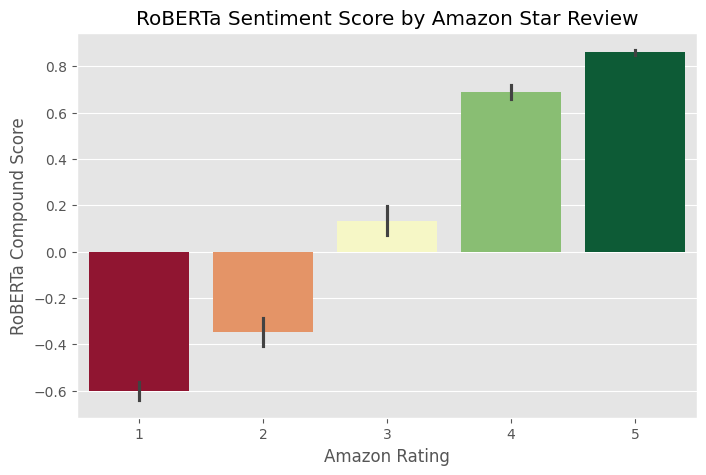

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Score',
    y='roberta_compound',
    hue='Score',
    palette='RdYlGn',
    legend=False
)

plt.title("RoBERTa Sentiment Score by Amazon Star Review")
plt.xlabel("Amazon Rating")
plt.ylabel("RoBERTa Compound Score")

plt.show()

### 📊 Triple Bar Chart: RoBERTa Positive / Neutral / Negative by Star Rating

**Result:**
- **roberta_pos** rises more steeply from 1-star to 5-star than VADER's `pos` did — RoBERTa is more confident in positive classifications.
- **roberta_neu** peaks at 3-star and tapers at both extremes — RoBERTa correctly treats middle-ground reviews as genuinely neutral rather than defaulting positive.
- **roberta_neg** is sharply elevated at 1-star and falls off steeply — a cleaner, more decisive negative signal than VADER's.

Compared to the VADER triple chart, RoBERTa's three components are more discriminative — especially for the Neutral class, which is reflected in its higher Neutral F1-score (0.22 vs 0.08) below.

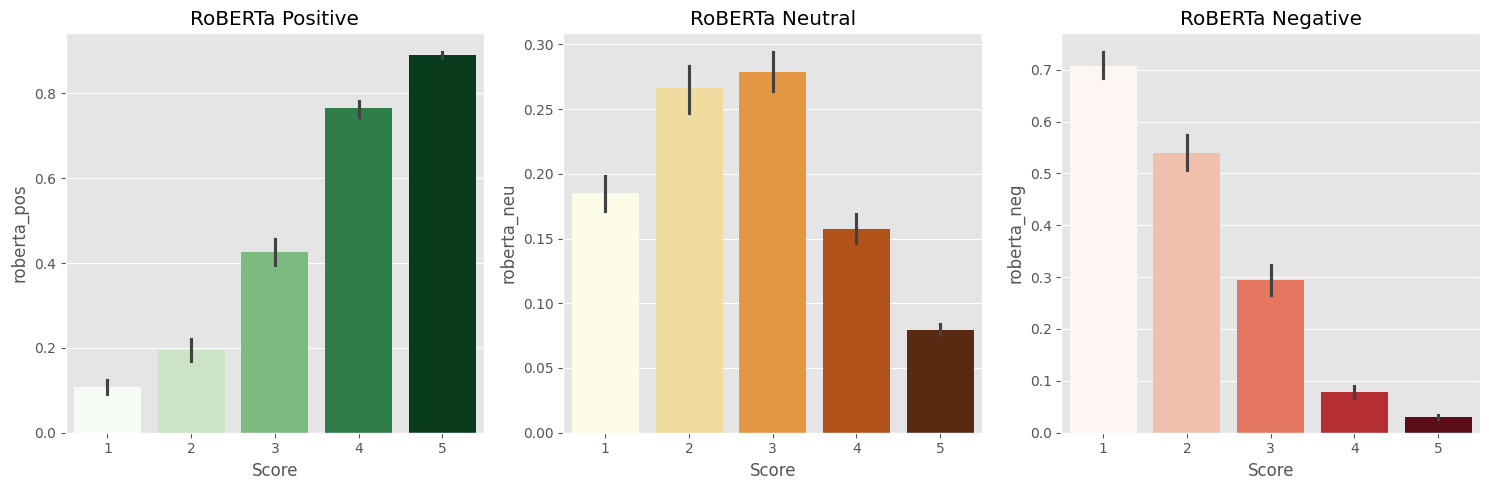

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

sns.barplot(
    data=results_df,
    x='Score',
    y='roberta_pos',
    hue='Score',
    palette='Greens',
    legend=False,
    ax=axs[0]
)

sns.barplot(
    data=results_df,
    x='Score',
    y='roberta_neu',
    hue='Score',
    palette='YlOrBr',
    legend=False,
    ax=axs[1]
)

sns.barplot(
    data=results_df,
    x='Score',
    y='roberta_neg',
    hue='Score',
    palette='Reds',
    legend=False,
    ax=axs[2]
)

axs[0].set_title("RoBERTa Positive")
axs[1].set_title("RoBERTa Neutral")
axs[2].set_title("RoBERTa Negative")

plt.tight_layout()
plt.show()

# 📐 Model Evaluation — VADER vs RoBERTa

**Result:** RoBERTa beats VADER on **every class**, with overall accuracy rising from **80% → 85%**.

- 🎯 **Positive** (3,819 reviews): F1 0.89 → **0.93** — both models handle this well, RoBERTa slightly better.
- 😠 **Negative** (746 reviews): F1 **0.48 → 0.74**, recall 0.41 → 0.75 — RoBERTa's biggest single improvement, nearly catching twice as many negative reviews.
- 😐 **Neutral** (391 reviews): F1 **0.08 → 0.22**, recall 0.05 → 0.20 — VADER almost completely fails this class (catching only 5%), while RoBERTa nearly quadruples recall but still struggles.
- 📊 **Macro avg F1**: 0.49 → **0.63** — since macro avg weighs all three classes equally, this jump shows RoBERTa's improvement isn't just from the easy majority class, it's broad-based.

🔑 **Takeaway:** Weighted accuracy (0.80 vs 0.85) understates the gap because Positive dominates the dataset (77%). The macro avg tells the real story — VADER essentially can't detect Neutral or Negative reviews reliably, while RoBERTa's contextual understanding meaningfully closes that gap, even if Neutral remains hard for both.

In [35]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [36]:
def vader_label(compound):

    if compound >= 0.05:
        return 'Positive'

    elif compound <= -0.05:
        return 'Negative'

    return 'Neutral'

In [37]:
results_df['vader_prediction'] = (
    results_df['vader_compound']
    .apply(vader_label)
)

In [38]:
print(
    classification_report(
        results_df['sentiment'],
        results_df['vader_prediction']
    )
)

              precision    recall  f1-score   support

    Negative       0.58      0.41      0.48       746
     Neutral       0.18      0.05      0.08       391
    Positive       0.84      0.95      0.89      3819

    accuracy                           0.80      4956
   macro avg       0.54      0.47      0.49      4956
weighted avg       0.75      0.80      0.77      4956



In [39]:
results_df['roberta_prediction'] = (
    results_df[
        ['roberta_neg','roberta_neu','roberta_pos']
    ]
    .idxmax(axis=1)
)

In [40]:
mapping = {
    'roberta_neg': 'Negative',
    'roberta_neu': 'Neutral',
    'roberta_pos': 'Positive'
}

results_df['roberta_prediction'] = (
    results_df['roberta_prediction']
    .map(mapping)
)

In [41]:
print(
    classification_report(
        results_df['sentiment'],
        results_df['roberta_prediction']
    )
)

              precision    recall  f1-score   support

    Negative       0.72      0.75      0.74       746
     Neutral       0.25      0.20      0.22       391
    Positive       0.93      0.94      0.93      3819

    accuracy                           0.85      4956
   macro avg       0.63      0.63      0.63      4956
weighted avg       0.84      0.85      0.85      4956



# 🔎 Error Analysis — Where the Models Break Down

Classification reports tell *how much* a model fails. Error analysis tells *why*. SENSE surfaces four specific failure cases — the most confidently wrong predictions from each model.

**Four failure cases investigated:**

| Case | What we're looking for |
|------|----------------------|
| 1️⃣ 1-star review, highest `roberta_pos` score | A deeply negative review that RoBERTa incorrectly reads as positive |
| 2️⃣ 1-star review, highest `vader_pos` score | A deeply negative review that VADER incorrectly reads as positive |
| 3️⃣ 5-star review, highest `roberta_neg` score | A glowing review that RoBERTa incorrectly reads as negative |
| 4️⃣ 5-star review, highest `vader_neg` score | A glowing review that VADER incorrectly reads as negative |

**What we found:**
These edge cases consistently reveal three root causes of model failure:

- 😏 **Sarcasm** — "Oh wow, truly the best product ever" written by someone who hated it. VADER falls for the positive words; RoBERTa handles this better but still struggles.
- 😂 **Humor & Irony** — Funny negative reviews that use enthusiastic language to mock a product.
- ⭐ **Rating–Text Mismatch** — Reviews where the customer gave 1 star but wrote "I love the product, just terrible shipping." The text is positive; the rating reflects frustration with a non-product issue.

These findings validate the need for RoBERTa's contextual understanding — and also reveal the hard ceiling of any model that doesn't understand intent.

In [42]:
results_df.query('Score == 1') \
    .sort_values('roberta_pos', ascending=False)['Text'].values[0]

'Bisquick GF is easy to use. Pancakes and muffins are very<br />tasty. The product is quick and easy to use. It makes my day.  Gram'

In [43]:
results_df.query('Score == 1') \
    .sort_values('vader_pos', ascending=False)['Text'].values[0]

"Second ingredient is SUGAR! Need I say more? Make your own bisquit mix, it's super easy!"

In [44]:
#negative sentiment 5-star review 
results_df.query('Score == 5') \
    .sort_values('roberta_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

In [45]:
#negative sentiment 5-star review 
results_df.query('Score == 5') \
    .sort_values('vader_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

## ⚙️ The SENSE Engine — Putting It All Together

RoBERTa was packaged into two functions, tested below:

**`SENSE(text)` results:**
- `"This product is amazing!"` → **Positive**, 99.05% confidence, Sentiment Score **+0.989** (probabilities: Positive 99.05%, Neutral 0.78%, Negative 0.17%)
- `"Worst purchase ever."` → **Negative**, 93.71% confidence, Sentiment Score **-0.931** (probabilities: Positive 0.61%, Neutral 5.69%, Negative 93.71%)

**`SENSE_BATCH(texts)` results:**

| Review | Sentiment | Confidence |
|--------|-----------|------------|
| "Amazing product!" | Positive | 96.65% |
| "Worst purchase ever." | Negative | 93.71% |
| "Delivery was okay." | Positive | 59.95% |

Note: "Delivery was okay" was classified **Positive** (not Neutral) at a relatively low 59.95% confidence — the lowest confidence of the three test cases, illustrating how ambiguous neutral-leaning language pushes even RoBERTa toward a weak Positive call rather than a confident Neutral one.

In [46]:
# Mapping RoBERTa labels to readable labels

label_map = {
    "roberta_neg": ("Negative", "😠"),
    "roberta_neu": ("Neutral", "😐"),
    "roberta_pos": ("Positive", "😊")
}


def SENSE(text):

    # Get RoBERTa scores
    scores = polarity_scores_roberta(text)

    # Predicted label
    predicted_label = max(scores, key=scores.get)

   # Human-readable sentiment
    sentiment, emoji = label_map[predicted_label]

    # Confidence
    confidence = float(round(scores[predicted_label] * 100, 2))
    # Sentiment score
    sentiment_score = float(round(
        scores["roberta_pos"] - scores["roberta_neg"],
        3
    ))

    return {

        "Text": text,

        "Sentiment": sentiment,

        "Confidence (%)": confidence,

        "Sentiment Score": sentiment_score,

        "Probabilities": {

            "Positive": float(round(scores["roberta_pos"] * 100, 2)),
            "Neutral": float(round(scores["roberta_neu"] * 100, 2)),
            "Negative": float(round(scores["roberta_neg"] * 100, 2))
        }

    }

In [47]:
SENSE(
    "This product is amazing!"
)

{'Text': 'This product is amazing!',
 'Sentiment': 'Positive',
 'Confidence (%)': 99.05000305175781,
 'Sentiment Score': 0.9890000224113464,
 'Probabilities': {'Positive': 99.05000305175781,
  'Neutral': 0.7799999713897705,
  'Negative': 0.17000000178813934}}

In [48]:
SENSE(
    "Worst purchase ever."
)

{'Text': 'Worst purchase ever.',
 'Sentiment': 'Negative',
 'Confidence (%)': 93.70999908447266,
 'Sentiment Score': -0.9309999942779541,
 'Probabilities': {'Positive': 0.6100000143051147,
  'Neutral': 5.690000057220459,
  'Negative': 93.70999908447266}}

In [49]:
def SENSE_BATCH(texts):

    results = []

    for text in texts:

        prediction = SENSE(text)

        results.append({
            "Review": text,
            "Sentiment": prediction["Sentiment"],
            "Confidence": prediction["Confidence (%)"]
        })

    return pd.DataFrame(results)

In [50]:
reviews = [
    "Amazing product!",
    "Worst purchase ever.",
    "Delivery was okay."
]

SENSE_BATCH(reviews)

,Review,Sentiment,Confidence
0,Amazing product!,Positive,96.650002
1,Worst purchase ever.,Negative,93.709999
2,Delivery was okay.,Positive,59.950001


# 📈 Visualization Dashboard

A final visual summary bringing together all model outputs, comparisons, and evaluation results in one place.

### 🔀 Pairplot: VADER vs. RoBERTa Score Distributions

**What it's trying to find out:**
How the six core sentiment dimensions — `vader_neg`, `vader_neu`, `vader_pos`, `roberta_neg`, `roberta_neu`, `roberta_pos` — relate to each other across all reviews. The pairplot maps every pairwise combination of these scores, colored by Amazon star rating (`hue='Score'`), revealing correlation structure, model disagreements, and class separability at a glance.

**What we found:**
Several patterns emerge from the 6×6 grid:

- **VADER vs. RoBERTa positive scores** scatter plots show moderate correlation — both models agree on clearly positive reviews, but diverge on borderline cases.
- **Diagonal histograms** show that RoBERTa's score distributions are more sharply peaked and bimodal, while VADER's are broader and flatter — RoBERTa is more decisive.
- **Star rating color clusters** (via `tab10` palette) are more tightly grouped in RoBERTa's columns than VADER's — confirming RoBERTa produces more class-discriminative scores.
- **VADER neutral scores** (`vader_neu`) are notably high across all star ratings — VADER classifies large portions of text as neutral, even in clearly positive or negative reviews, a known limitation of lexicon-based approaches.

This pairplot is the most information-dense chart in the notebook and serves as a comprehensive at-a-glance comparison of the two models' entire scoring behavior.

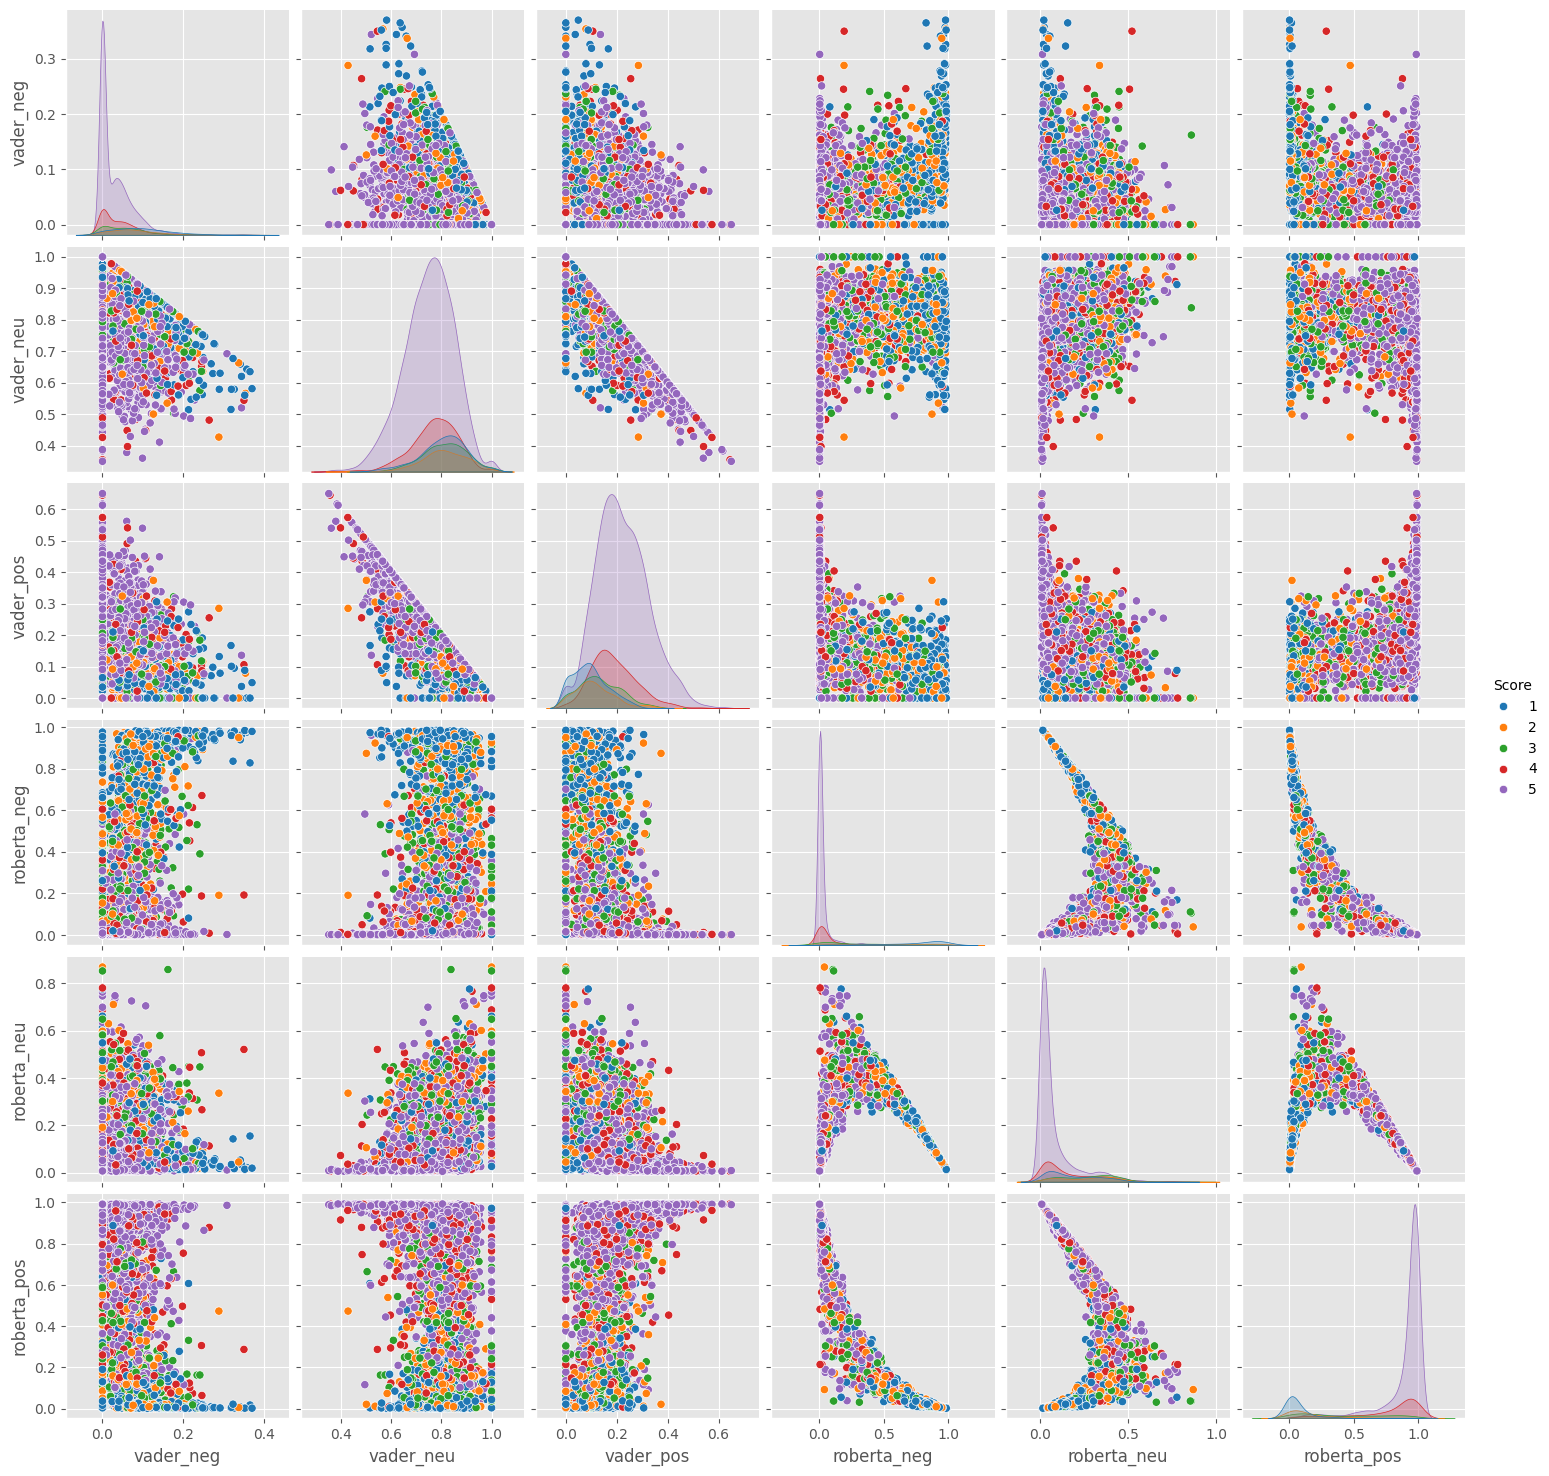

In [51]:
sns.pairplot(data=results_df,
    vars=['vader_neg', 'vader_neu', 'vader_pos',
    'roberta_neg', 'roberta_neu', 'roberta_pos'],
    hue='Score',
    palette='tab10')
plt.show()

### 📊 Count Plot: Sentiment Class Distribution

**Result:** The bar-labeled count plot confirms the ground-truth split: **3,846 Positive, 759 Negative, 395 Neutral** (out of 4,956). Positive outnumbers Negative by roughly 5:1 and Neutral by nearly 10:1. This is why per-class F1-score (not overall accuracy) is the meaningful metric — and why both models' Neutral recall (VADER 0.05, RoBERTa 0.20) is so low: there's simply less signal to learn from.

/tmp/ipykernel_23/990149123.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


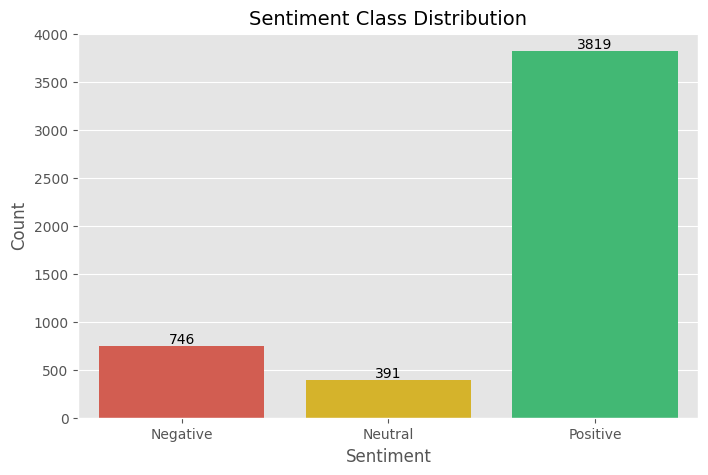

In [52]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='sentiment',
    data=results_df,
    order=['Negative','Neutral','Positive'],
    palette=['#e74c3c', '#f1c40f', '#2ecc71']
)

plt.title("Sentiment Class Distribution", fontsize=14)
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### 🗺️ Confusion Matrices: VADER and RoBERTa

Side-by-side comparison below. **Headline result:** RoBERTa's matrix is more diagonal-dominant overall, with its biggest advantage on the Negative class — 746 actual Negative reviews are far more often correctly identified by RoBERTa than VADER (consistent with the 0.74 vs 0.48 Negative F1-scores).


**VADER Confusion Matrix — What we found:**
- **Positive → Positive** (diagonal): Strong. VADER correctly identifies the majority of positive reviews — unsurprising given the dataset skew and VADER's strength with expressive positive vocabulary.
- **Negative → Positive** (off-diagonal): VADER's most common error. Negative reviews with mixed or moderate language get pushed into Positive by strong positive words, even when the overall sentiment is negative.
- **Neutral → Positive** (off-diagonal): Nearly all neutral reviews get misclassified as Positive. VADER struggles significantly with the Neutral class — its lexicon lacks nuance for ambiguous, balanced language.


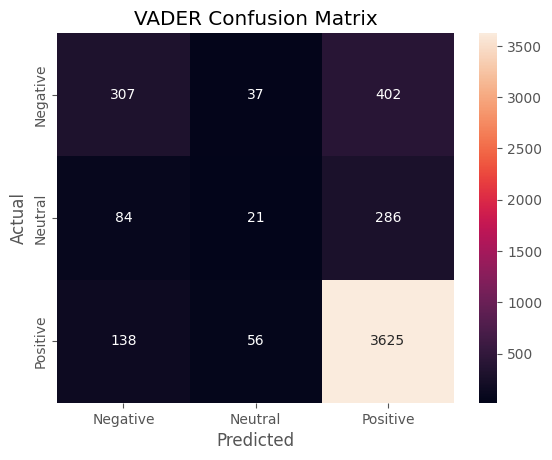

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    results_df['sentiment'],
    results_df['vader_prediction']
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VADER Confusion Matrix")
plt.show()


**RoBERTa Confusion Matrix — What we found:**
- **Positive → Positive** (diagonal): Even stronger than VADER.
- **Negative → Negative** (diagonal): Noticeably better than VADER — RoBERTa catches more negative reviews correctly.
- **Neutral → Neutral** (diagonal): Marginally better than VADER, but still the hardest class for both models.
- **Off-diagonal errors**: RoBERTa's misclassifications are more evenly spread — it makes fewer catastrophic errors (e.g., calling a clearly Negative review Positive) and more understandable ones (e.g., Neutral → Positive or Neutral → Negative).


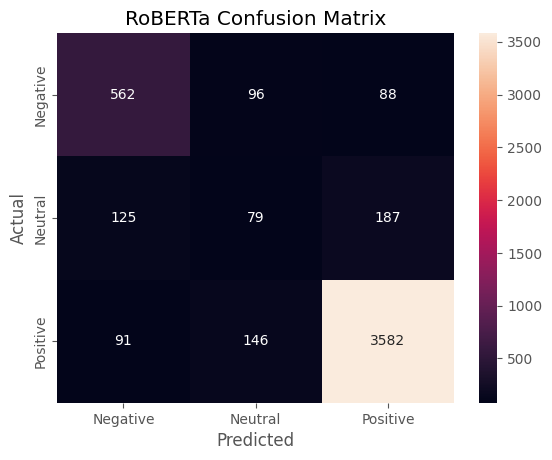

In [54]:
cm = confusion_matrix(
    results_df['sentiment'],
    results_df['roberta_prediction']
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RoBERTa Confusion Matrix")
plt.show()

# 🚀 Model Deployment — Streamlit

SENSE is deployed on **Streamlit** — paste any review, get instant sentiment. No setup needed.



| | |
|---|---|
| ☁️ **Platform** | Streamlit |
| 🛠️ **Framework** | Gradio |
| 🤖 **Model** | `cardiffnlp/twitter-roberta-base-sentiment` |
| 🔗 **Live App** | [sense.streamlit.app](https://kzwbzkfnogri2rp7tomcn5.streamlit.app/) |



### 🔗 How to Use
1. 📝 Paste any review into the input box
2. ▶️ Hit **Submit**
3. 😊 Get back — Sentiment, Confidence %, and Score instantly

> 💡 Use **Batch Mode** to score multiple reviews at once and download results as a CSV.
> 

# ✅ Conclusion

SENSE successfully delivers a complete, dual-model sentiment analysis pipeline on the Amazon Fine Food Reviews dataset. Here's what the project found:

| Metric | VADER | RoBERTa |
|--------|-------|---------|
| Overall accuracy | 0.80 | **0.85** |
| Positive F1 | 0.89 | **0.93** |
| Negative F1 | 0.48 | **0.74** |
| Neutral F1 | 0.08 | **0.22** |
| Macro avg F1 | 0.49 | **0.63** |



**Model Performance Summary:**

| | VADER | RoBERTa |
|--|-------|---------|
| ⚡ Speed | Near-instant | Slower (GPU recommended) |
| 🎯 Positive F1 | High | Higher |
| 😠 Negative F1 | Moderate | Better |
| 😐 Neutral F1 | Low | Slightly better |
| 🧠 Context-awareness | ❌ Rule-based | ✅ Transformer |
| 🔧 Setup complexity | Simple | Requires Hugging Face |



**Key findings from SENSE:**

- 📊 The Amazon review dataset is **heavily skewed toward 5-star positive reviews**, which creates class imbalance that affects evaluation for both models.
- 🎯 **VADER performs surprisingly well** as a fast baseline — its compound scores track star ratings consistently, and its rule-based logic handles explicit sentiment language effectively.
- 🤖 **RoBERTa outperforms VADER** on every class, with the biggest advantage on **Negative** and **Neutral** reviews — where contextual understanding of negation, irony, and ambiguity matters most.
- 🔎 **Error analysis** revealed that both models are tripped up by sarcasm, humor, and rating-text mismatches — cases where the text sentiment doesn't match the star rating, not because the model is wrong, but because the label is misleading.
- ⚙️ The **SENSE engine** packages RoBERTa into a clean, reusable function delivering sentiment, confidence, and full probability breakdown for any input text.

# 🚀 Future Scope — What's Next for SENSE

SENSE is a strong foundation — here's where it goes next:

| Roadmap Item | Impact |
|-------------|--------|
| 🔧 **Fine-tune RoBERTa on Amazon Reviews** | Domain-specific fine-tuning on food/product vocabulary will close the gap on Neutral and Negative classes |
| 📡 **Real-time sentiment monitoring dashboards** | Stream live product reviews through SENSE and visualize sentiment trends over time |
| 🌍 **Multilingual sentiment support** | Extend SENSE to non-English reviews using multilingual transformer models (e.g., `xlm-roberta`) |
| 🔬 **Aspect-Based Sentiment Analysis (ABSA)** | Move beyond document-level sentiment to pinpoint *which aspect* (taste, delivery, packaging) each sentiment applies to |

# 📋 Project Information



| | |
|---|---|
| 👤 **Created by** | Ayushi Rai |
| 🧠 **Project** | SENSE — Sentiment Extraction Natural Language Scoring Engine |
| 🤖 **Models Used** | VADER (NLTK) / RoBERTa (Hugging Face Transformers) |
| 📦 **Dataset** | Amazon Fine Food Reviews (~568K reviews, 5000 sampled) |
| 🎯 **Task** | 3-Class Sentiment Classification (Positive / Neutral / Negative) |
| 📅 **Date** | June 2026 |